In [1]:
from flow_helpers import *

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)

### Simulating pulsar

In [428]:
psrs = [allpsrs[0]] 
psr = psrs[0]
npsr = len(psrs)

Tspan = ds.getspan(psrs)
rn_components = 30

tnequad = False
ecorr = False
fixed_wn = True

psl = ds.PulsarLikelihood([
    psr.residuals,
    ds.makenoise_measurement(psr, psr.noisedict, tnequad = tnequad, ecorr = ecorr),
    ds.makegp_timing(psr, svd=True, variance=1e-20),
    ds.makegp_fourier(psr, ds.powerlaw, rn_components, name='red_noise', T=Tspan)
])

In [429]:
sampler = psl.sample

# Sample parameters from prior
params_inj = {f'{psr.name}_red_noise_log10_A': -11.5,
 f'{psr.name}_red_noise_gamma': 2}#ds.sample_uniform(sampler.params)

# Generate residuals
key = ds.rngkey(0)
key, residuals = sampler(key, params_inj)

print(f"Generated {len(residuals)} residuals")

Generated 59389 residuals


In [430]:
params_inj

{'J1713+0747_red_noise_log10_A': -11.5, 'J1713+0747_red_noise_gamma': 2}

In [431]:
# Replace residuals (cast to numpy array)
psr.residuals = np.array(residuals)
psrs = [psr]

Text(0, 0.5, '$r \\ [\\mathrm{\\mu s}]$')

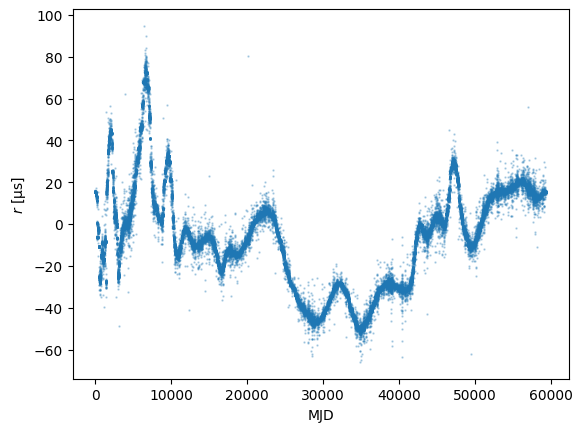

In [432]:
plt.scatter(np.arange(len(residuals)), residuals/1e-6, s= 0.5, alpha = 0.3)
plt.xlabel(r"MJD")
plt.ylabel(r"$r \ [\mathrm{\mu s}]$")

### Creating fouriermodel for fake pulsar

In [453]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw

rn_params = {"log10_A": -18.0, "gamma": 6.0} # we can set this to whatever we like, the MAP search helps us find "optimal" choice

pslmodels_inj = [ds.PulsarLikelihood([psr.residuals,
                                          ds.makegp_timing(psr, svd=True, variance = 1e-20),
                                          ds.makenoise_measurement(psr, noisedict=psr.noisedict, tnequad=tnequad, ecorr=ecorr),
                                          ds.makegp_fourier(psr, ds.partial(powerlaw, **rn_params),
                                                            rn_components, name='red_noise', T=Tspan)])]
 #   else:
        
#rn_params = {"log10_A": params[f"{psr.name}_red_noise_log10_A"], "gamma": params[f"{psr.name}_red_noise_gamma"]}
#pslmodels_fake = fouriermodel(psrs, rn_components, 
#                                 rn_init_params=rn_params, ecorr = ecorr, tnequad = tnequad, 
#                                 powerlaw = powerlaw, fixed_wn = fixed_wn, residuals = psr.residuals)

In [454]:
psr_noisedicts = [psr.noisedict for psr in psrs]
L0s, ahat0_list, _ = compute_zero_quantities(pslmodels_inj, psr_noisedicts)
L0s = jnp.stack(L0s)
ahat0_list = jnp.stack(ahat0_list)
Sigma_0_inv = jax.vmap(lambda L0: jnp.linalg.inv(L0 @ L0.T))(L0s)

b0s = jax.vmap(lambda L0, ahat0: jsp.linalg.cho_solve((L0, True), ahat0))(L0s, ahat0_list)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

TtNT, _ = TtNT_mpsrs(Sigma_0_inv, params_list=[rn_params] * npsr,
                                f=f, df=df, powerlaw=powerlaw)

psrnames = [psr.name for psr in pslmodels_inj]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)



In [455]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

### MAP estimate from grid search

In [456]:
eta_0 = None

for psr_idx in range(1):
    psrs_subset = [psrs[psr_idx]]

    rn_amp_key_subset = [rn_amp_keys[psr_idx]]    
    rn_gamma_key_subset = [rn_gamma_keys[psr_idx]]  

    commongp = ds.makecommongp_fourier(psrs_subset, ds.powerlaw, rn_components,
                                        T=Tspan, name='red_noise')
    commongp_crn = ds.makecommongp_fourier(psrs_subset, ds.powerlaw,
                                            components=crn_components, T=Tspan, name='crn',
                                            common=[crn_log10A_key, crn_gamma_key],)

    getN_common = commongp.Phi.getN
    getN_crn = commongp_crn.Phi.getN

    phi_crn_args = (crn_components, rn_amp_key_subset, rn_gamma_key_subset,
                    crn_log10A_key, crn_gamma_key, getN_common, getN_crn)

    phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

    log_posterior = make_marginalized_log_posterior(
        TtNT[psr_idx], b0s[psr_idx], phi_crn_partial, 
        rn_amp_key_subset, rn_gamma_key_subset,
    crn_log10A_key, crn_gamma_key, n_crn_grid=20)

    eta_0 = eta_MAP(log_posterior,n_grid = 20, steps = 7, zoom = 0.5)

    print(f"eta MAP for {psrs[psr_idx].name}: {jnp.round(jnp.array(eta_0), 2)}")

eta MAP for J1713+0747: [  1.54 -11.51]


### Run flow model with fake pulsar using MAP estimate

In [457]:
rn_init_params = {'log10_A': eta_0[1], 'gamma': eta_0[0]}

#pslmodels = [ds.PulsarLikelihood([psr.residuals,
#                                          ds.makegp_timing(psr, svd=True, variance = 1e-20),
#                                          ds.makenoise_measurement(psr, noisedict=psr.noisedict, tnequad=tnequad, ecorr=ecorr),
#                                          ds.makegp_fourier(psr, ds.partial(powerlaw, **rn_init_params),
#                                                            rn_components, name='red_noise', T=Tspan)])]

pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, ecorr = ecorr, tnequad = tnequad, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn, 
                                 residuals=[psr.residuals])

psr_noisedicts = [psr.noisedict for psr in psrs]
L0s, ahat0_list, _ = compute_zero_quantities(pslmodels, psr_noisedicts)

L0s = jnp.stack(L0s)
ahat0_list = jnp.stack(ahat0_list)


In [458]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

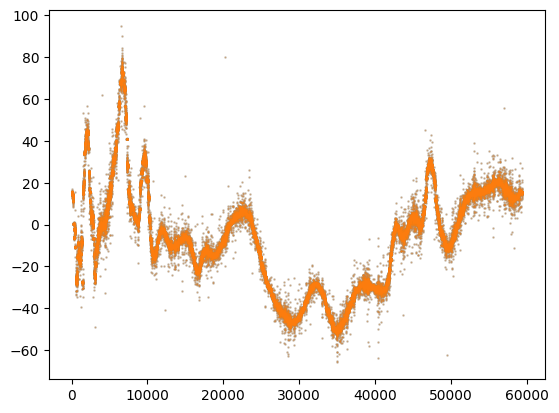

In [459]:
plt.scatter(np.arange(len(residuals)), pslmodels[0].y/1e-6, s = 0.5, alpha = 0.3)
plt.scatter(np.arange(len(residuals)), psr.residuals/1e-6, s= 0.5, alpha = 0.3)

### Fitting flow

In [460]:
num_samples = 64 
num_params  = 2*rn_components
rng = jax.random.key(0)

# choose your flow
flow_key, rng = jax.random.split(rng)
flow = masked_autoregressive_flow( flow_key, base_dist=StandardNormal((num_params,)),
    flow_layers=2, nn_width=16, nn_depth=4, invert=True)

# fitting a flow
trained_flows, train_keys = fit_flows(pslmodels, logxs, ahat0_list, L0s, 
                                    num_samples, rng, flow = flow)

Fitting flow for pulsar J1713+0747


 23%|██▎       | 226/1001 [00:13<00:45, 17.01it/s, loss=-806349.08]

Early stopping at iteration 226


### Estimating flow quantities

In [461]:
# computing _f quantities
num_flow_samples = 500000 # rather large to get good estimate of ahat_f and Sigma_f from samples
ahat_f, Sigma_f, L_f = gauss_approx_flow_mpsrs(trained_flows, train_keys, ahat0_list, 
                                               L0s, num_flow_samples=num_flow_samples)

# precomputing quantities needed in likelihood model
Sigma_f_inv, logdet_arr, b_flow, quad_f = eval_flow_quantity_mpsrs(ahat_f, Sigma_f, L_f)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

# extracting TtNT for all psrs
TNT_flow, logdet_phi0 = TtNT_mpsrs(Sigma_f_inv, params_list=[rn_init_params],
                                f=f, df=df, powerlaw=powerlaw)

log_const = 0.5 * logdet_phi0


In [ ]:

def make_model_crn_flow(b, phi, log_const, TNT, npsr, rn_components,
                        rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key,
                        ahat_0, L_0, ahat_f, L_sigma_f, logL_flow_list,):
    
    # checking shapes so that computations can be batched over psrs
    if TNT.shape != (npsr, 2 * rn_components, 2 * rn_components):
        TNT = TNT.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)
    
    if b.shape != (npsr, 2 * rn_components):
        b = b.reshape(npsr, 2 * rn_components)
    
    if L_sigma_f.shape != (npsr, 2 * rn_components, 2 * rn_components):
        L_sigma_f = L_sigma_f.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)
    
    if ahat_f.shape != (npsr, 2 * rn_components):
        ahat_f = ahat_f.reshape(npsr, 2 * rn_components)
        
    if ahat_0.shape != (npsr, 2 * rn_components):
        ahat_0 = ahat_0.reshape(npsr, 2 * rn_components)
        
    if L_0.shape != (npsr, 2 * rn_components, 2 * rn_components):
        L_0 = L_0.reshape(npsr, 2 * rn_components, npsr, 2 * rn_components).diagonal(axis1=0, axis2=2).transpose(2, 0, 1)

    def model_crn():
        # TODO: same here, read in bounds from prior instead of hardcoding
        etas = {}
        for k in rn_amp_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(-20, -11))
        for k in rn_gamma_keys:
            etas[k] = numpyro.sample(k, dist.Uniform(0, 7))
        etas[crn_log10A_key] = numpyro.sample(crn_log10A_key, dist.Uniform(-20, -11))
        etas[crn_gamma_key]  = numpyro.sample(crn_gamma_key,  dist.Uniform(0, 7))


        xis = numpyro.sample("xi", dist.Normal(jnp.zeros((npsr, 2 * rn_components)),
                                        jnp.ones((npsr, 2 * rn_components))))

        phi_inv_diags, logdet_phi = phi(etas)
        sigma_inv = TNT + jax.vmap(jnp.diag)(phi_inv_diags)
        L_sinv = jax.vmap(jnp.linalg.cholesky)(sigma_inv)
        
        ahat = jax.vmap(lambda l0, bv: jsp.linalg.cho_solve((l0, True), bv))(L_sinv, b)
        
        Sigma = jax.vmap(lambda l0: jsp.linalg.cho_solve((l0, True), jnp.eye(2 * rn_components)))(L_sinv)

        L_sigma = jax.vmap(jnp.linalg.cholesky)(Sigma)

        a = numpyro.deterministic("a", ahat + jax.vmap(jnp.dot)(L_sigma, xis))

        quad_b = jnp.sum(jax.vmap(jnp.dot)(b, ahat))
        log_det_L = -jnp.sum(jax.vmap(lambda l0: jnp.sum(jnp.log(jnp.diag(l0))))(L_sinv))
        logL = 0.5 * quad_b - 0.5 * logdet_phi + log_const + log_det_L
        numpyro.factor("logL", logL)

        # flow-correction part
        a_diff_0 = a - ahat_0
        y = jax.vmap(lambda l, r: jsp.linalg.solve_triangular(l, r, lower=True))(L_0, a_diff_0)
        numpyro.deterministic("y", y)
        log_p_flow = jnp.sum(jnp.array([logL_flow_list[i](y[i]) for i in range(npsr)]))

        #y_penalty = -0.5 * jnp.sum(y ** 2) / (10** 2) 
        #numpyro.factor("y_regularizer", y_penalty)
        
        log_p_flow = jnp.sum(jnp.array([logL_flow_list[i](y[i]) for i in range(npsr)]))
        
        a_diff = a - ahat_f
        y_gauss = jax.vmap(lambda l0, r: jsp.linalg.solve_triangular(l0, r, lower=True))(L_sigma_f, a_diff)
        log_p_gauss = -0.5 * jnp.sum(y_gauss ** 2)
        numpyro.deterministic("y_gauss", y_gauss)

        numpyro.factor("logFlow_correction", log_p_flow - log_p_gauss)

    return model_crn





In [479]:
logL_flow_list = [flow.log_prob for flow in trained_flows]

base_model_args = (b_flow, phi_crn_partial, log_const, TNT_flow, npsr, rn_components,
                   rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key,)

flow_model = make_model_crn_flow( *base_model_args, logL_flow_list=logL_flow_list,
    ahat_0=jnp.stack(ahat0_list), L_0=jnp.stack(L0s), ahat_f=ahat_f, L_sigma_f=L_f,)

init_params = {**{k: float(eta_0[1]) for k in rn_amp_keys},
          **{k: float(eta_0[0]) for k in rn_gamma_keys},
          crn_log10A_key: float(eta_0[1]),  
          crn_gamma_key: float(eta_0[0]),
           "xi": jnp.zeros((npsr, 2 * rn_components))}

kernel_flow  = infer.NUTS(flow_model, max_tree_depth = 10, target_accept_prob=0.6)
sampler_flow = infer.MCMC(kernel_flow, num_warmup=500, num_samples=1000)
sampler_flow.run(jax.random.PRNGKey(2), init_params = init_params)
samples_flow = sampler_flow.get_samples()
sampler_flow.print_summary()

sample: 100%|██████████| 1500/1500 [02:38<00:00,  9.45it/s, 7 steps of size 5.96e-01. acc. prob=0.62]  


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.67      0.25      1.67      1.20      2.02    382.88      1.01
  J1713+0747_red_noise_log10_A    -11.53      0.04    -11.53    -11.60    -11.46    555.09      1.00
                     crn_gamma      3.14      1.90      2.97      0.00      5.97    661.70      1.00
                   crn_log10_A    -16.04      2.36    -16.09    -20.00    -12.71    415.33      1.00
                       xi[0,0]     -0.06      1.08     -0.04     -1.72      1.80   1333.16      1.00
                       xi[0,1]      0.05      0.99      0.05     -1.54      1.69   1164.79      1.00
                       xi[0,2]      0.06      1.08      0.04     -1.65      1.74    947.57      1.00
                       xi[0,3]     -0.01      0.98     -0.04     -1.64      1.50   1236.33      1.00
                       xi[0,4]     -0.02      1.02     -0.06     -1.68      1.62   1859.33

In [480]:
y_flow_support = trained_flows[psr_idx].sample(jax.random.key(0), sample_shape=(5000,))
y_samples = samples_flow["y"][:,0,:]

(array([0.00944143, 0.00314714, 0.02202999, 0.0377657 , 0.06923712,
        0.08811997, 0.09126711, 0.25177134, 0.23288849, 0.29583132,
        0.29268418, 0.38080415, 0.33044988, 0.23288849, 0.23603563,
        0.1888285 , 0.14791566, 0.09126711, 0.05035427, 0.02517713,
        0.01573571, 0.02832428, 0.01888285, 0.00314714, 0.00314714]),
 array([-3.60804586, -3.29029722, -2.97254858, -2.65479994, -2.3370513 ,
        -2.01930266, -1.70155402, -1.38380538, -1.06605674, -0.7483081 ,
        -0.43055946, -0.11281082,  0.20493782,  0.52268646,  0.8404351 ,
         1.15818374,  1.47593238,  1.79368102,  2.11142966,  2.4291783 ,
         2.74692694,  3.06467558,  3.38242422,  3.70017286,  4.0179215 ,
         4.33567014]),
 <BarContainer object of 25 artists>)

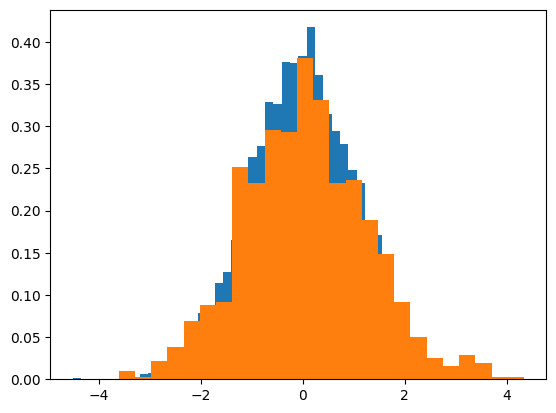

In [481]:
plt.hist(y_flow_support[:,0], bins = 'auto', density = True)
plt.hist(y_samples[:,0], bins = 'auto', density = True)

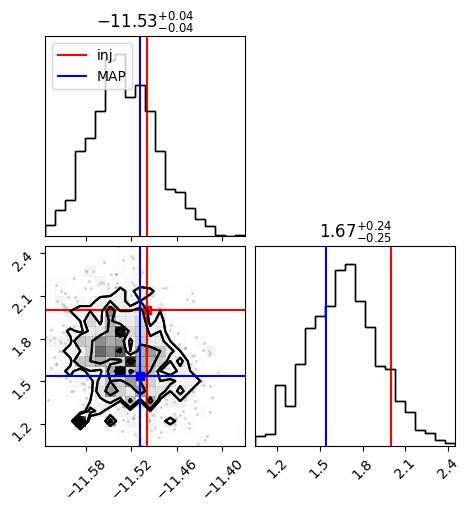

In [ ]:
irn_samples_flow = {k: np.array(samples_flow[k]) for k in rn_amp_keys + rn_gamma_keys}

truths_inj = [float(params_inj[k]) for k in rn_amp_keys + rn_gamma_keys]
truths_map = [float(eta_0[1]) if 'log10_A' in k else float(eta_0[0]) 
              for k in rn_amp_keys + rn_gamma_keys]

labels = rn_amp_keys + rn_gamma_keys

fig = corner.corner(np.column_stack([irn_samples_flow[k] for k in labels]),
    truths=truths_inj, truth_color='red', show_titles=True)

corner.corner( np.column_stack([irn_samples_flow[k] for k in labels]),
    truths=truths_map, truth_color='blue', fig=fig)

fig.axes[0].plot([], [], color='red',  label='inj')
fig.axes[0].plot([], [], color='blue', label='MAP')
fig.axes[0].legend(loc='upper left')

plt.show()

### Compute the JS divergence

In [344]:
from scipy.stats import gaussian_kde
from scipy.spatial import distance
def samples_to_prob_kde(samples, x_grid):
    kde  = gaussian_kde(samples)
    prob = kde(x_grid)
    return prob / prob.sum()

y_grid = np.linspace(-1000, 1000, 100000)

coeffidx = 0
p = samples_to_prob_kde(np.array(y_flow_support[:, coeffidx]), y_grid)
q = samples_to_prob_kde(np.array(y_samples[:, coeffidx]), y_grid)

js = distance.jensenshannon(p, q)
print(f"JS dim 0 (KDE): {js:.4f}")

JS dim 0 (KDE): 0.2669


# Grid scan with fixed $\boldsymbol \theta_0, \boldsymbol \eta_0$

In [ ]:
import pandas as pd
from scipy.spatial import distance
from scipy.stats import gaussian_kde
import itertools

log10A_grid = np.linspace(-20, -11, 10)
gamma_grid  = np.linspace(0,  7.0, 10)

csv_path = pathlib.Path(f'js_sensitivity_grid_{allpsrs[0].name}.csv')

def compute_js_per_dim(y_flow_support, y_mcmc, n_coeff = 2*rn_components):
        
        combined = np.concatenate([y_flow_support, y_mcmc], axis=0)
        y_grid = np.linspace(combined.min(), combined.max(), 1000)

        js_vals = []
        for d in range(n_coeff):
                # approximate samples using gaussian kde
                p = samples_to_prob_kde(np.array(y_flow_support[:, d]), y_grid)
                q = samples_to_prob_kde(np.array(y_mcmc[:, d]),  y_grid)
                js_vals.append(float(distance.jensenshannon(p, q)))
                
        return np.array(js_vals)

def samples_to_prob_kde(samples, x_grid):
        
        kde  = gaussian_kde(samples)
        
        prob = kde(x_grid)
        prob = np.clip(prob, 1e-300, None) 
        prob_sum = prob.sum()
        
        if not np.isfinite(prob_sum) or prob_sum == 0:
                return np.full_like(prob, 1.0 / len(prob))
        return prob / prob_sum

def append_result(row, path):
        df_row = pd.DataFrame([row])
        df_row.to_csv(path, mode='a', header=not path.exists(), index=False)
    
psrs = [allpsrs[0]] 
psr = psrs[0]
npsr = len(psrs)

Tspan = ds.getspan(psrs)
rn_components = 30

tnequad = False
ecorr = False
fixed_wn = True

powerlaw = ds.powerlaw

psl = ds.PulsarLikelihood([
    psr.residuals,
    ds.makenoise_measurement(psr, psr.noisedict, tnequad = tnequad, ecorr = ecorr),
    ds.makegp_timing(psr, svd=True, variance=1e-20),
    ds.makegp_fourier(psr, ds.powerlaw, rn_components, name='red_noise', T=Tspan)])

psrnames = [psr.name for psr in psrs]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

sampler = psl.sample

for log10_A, gamma in itertools.product(log10A_grid, gamma_grid):
    print(f"\nRunning: log10_A={log10_A:.2f}, gamma={gamma:.2f}")
    
    # inject rn and simulate psr residuals
    fixed_rn = {f"{psr.name}_red_noise_log10_A": log10_A,
            f"{psr.name}_red_noise_gamma":   gamma,}
    
    params_sim = ds.sample_uniform(sampler.params)
    params_sim.update(fixed_rn)
    
    key = ds.rngkey(0)
    key, residuals = sampler(key, params_sim)
    psr.residuals = np.array(residuals)
    psrs = [psr]

    rn_params = {"log10_A": float(log10_A), "gamma": float(gamma)}

    # building pslmodel based on the inj. signal
    pslmodels_fake = fouriermodel(psrs, rn_components,
            rn_init_params=rn_params, ecorr=ecorr, tnequad=tnequad,
            powerlaw=powerlaw, fixed_wn=fixed_wn, residuals=[psr.residuals])

    psr_noisedicts_g = [psr.noisedict]
    L0s_g, ahat0_g, _ = compute_zero_quantities(pslmodels_fake, psr_noisedicts_g)
    L0s_g       = jnp.stack(L0s_g)
    ahat0_arr_g = jnp.stack(ahat0_g)
    
    Sigma_0_inv_g = jax.vmap(lambda L0: jnp.linalg.inv(L0 @ L0.T))(L0s_g)
    b0s_g = jax.vmap(lambda L0, a: jsp.linalg.cho_solve((L0, True), a))(L0s_g, ahat0_arr_g)

    _, f, df = construct_freqs(psrs, num_frequencies=rn_components)
    TtNT_g, _ = TtNT_mpsrs(Sigma_0_inv_g, params_list=[rn_params]*npsr,
                                f=f, df=df, powerlaw=powerlaw)

    # compute the MAP
    psrs_subset = [psrs[0]]
    rn_amp_key_subset = [rn_amp_keys[0]]
    rn_gamma_key_subset = [rn_gamma_keys[0]]

    commongp = ds.makecommongp_fourier(psrs_subset, ds.powerlaw,
                           rn_components, T=Tspan, name='red_noise')
    commongp_crn = ds.makecommongp_fourier(psrs_subset, ds.powerlaw,
                           components=crn_components, T=Tspan, name='crn',
                           common=[crn_log10A_key, crn_gamma_key])

    phi_crn_args_g = (crn_components, rn_amp_key_subset, rn_gamma_key_subset,
                             crn_log10A_key, crn_gamma_key,
                             commongp.Phi.getN, commongp_crn.Phi.getN)
    phi_crn_partial_g = jax.jit(lambda rho, args=phi_crn_args_g: phi_crn(rho, *args))

    log_post_g = make_marginalized_log_posterior(
            TtNT_g[0], b0s_g[0], phi_crn_partial_g,
            rn_amp_key_subset, rn_gamma_key_subset,
            crn_log10A_key, crn_gamma_key, n_crn_grid=35)

    eta_0_g = eta_MAP(log_post_g, n_grid=20, steps=6, zoom=0.5)
    print(f"eta_0 MAP estimate: gamma={float(eta_0_g[0]):.3f}, log10_A={float(eta_0_g[1]):.3f}")

    # create pslmodel using MAP estimate
    rn_init_g   = [{'log10_A': float(eta_0_g[1]), 'gamma': float(eta_0_g[0])}]
    pslmodels_g = fouriermodel(psrs, rn_components,
                                   rn_init_params=rn_init_g,
                                   ecorr=ecorr, tnequad=tnequad,
                                   powerlaw=powerlaw, fixed_wn=fixed_wn,
                                   residuals=[psr.residuals])

    logxs_g = [simple_dict_transformation(pslmodels_g[i].clogL)
                   for i in range(npsr)]

    Ls_g, ahat0_flow_g, _ = compute_zero_quantities(pslmodels_g, psr_noisedicts_g)
    Ls_g = jnp.stack(Ls_g)
    ahat0_flow_g  = jnp.stack(ahat0_flow_g)
    
    # fit a flow
    rng_g = jax.random.key(0)
    flow_key_g, rng_g = jax.random.split(rng_g)
    flow_g = masked_autoregressive_flow(
    flow_key_g, base_dist=StandardNormal((2*rn_components,)),
    flow_layers=2, nn_width=16, nn_depth=4, invert=True)

    trained_flows_g, train_keys_g = fit_flows(pslmodels_g, logxs_g, ahat0_flow_g, Ls_g,
            num_samples=64, rng=rng_g, flow=flow_g)

    # get Gaussian approx.
    ahat_f_g, Sigma_f_g, L_f_g = gauss_approx_flow_mpsrs(
            trained_flows_g, train_keys_g, ahat0_flow_g, Ls_g,
            num_flow_samples=500000)
    Sigma_f_inv_g, logdet_arr_g, b_flow_g, quad_f_g = eval_flow_quantity_mpsrs(
            ahat_f_g, Sigma_f_g, L_f_g)

    TNT_flow_g, logdet_phi0_g = TtNT_mpsrs(
            Sigma_f_inv_g, params_list=[rn_init_g[0]]*npsr,
            f=f, df=df, powerlaw=powerlaw)
        
    print("Gaussian approximation done!")
    
    logL_flow_list_g = [fl.log_prob for fl in trained_flows_g]

    base_model_args_g = (b_flow_g, phi_crn_partial_g, 0.5*logdet_phi0_g,
                             TNT_flow_g, npsr, rn_components,
                             rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key)

    flow_model_g = make_model_crn_flow(*base_model_args_g,
            logL_flow_list=logL_flow_list_g,
            ahat_0=ahat0_flow_g, L_0=Ls_g,
            ahat_f=ahat_f_g, L_sigma_f=L_f_g)

    init_g = {**{k: float(eta_0_g[1]) for k in rn_amp_keys},
                  **{k: float(eta_0_g[0]) for k in rn_gamma_keys},
                  crn_log10A_key: -15.0, crn_gamma_key: 4.0,
                  "xi": jnp.zeros((npsr, 2*rn_components))}
    
    # start sampling
    sampler_g = infer.MCMC(infer.NUTS(flow_model_g, target_accept_prob = 0.6),
                               num_warmup=1000, num_samples=2000,
                               progress_bar=True)
        
    sampler_g.run(jax.random.PRNGKey(0), init_params=init_g)
    samples_g = sampler_g.get_samples()

    # jsd evaluation
    y_flow_g = np.array(trained_flows_g[0].sample(
            jax.random.key(0), sample_shape=(2000,)))
    y_mcmc_g = np.array(samples_g["y"][:, 0, :])
    js_dims  = compute_js_per_dim(y_flow_g, y_mcmc_g)

    row = {'log10_A': log10_A, 'gamma': gamma,
            'js_mean': js_dims.mean(), 'js_std': js_dims.std(), 'js_max': js_dims.max(),
            'eta0_gamma':  float(eta_0_g[0]), 'eta0_log10A': float(eta_0_g[1]),}
    
    # appending result sequentially
    append_result(row, csv_path)



Running: log10_A=-20.00, gamma=0.00
eta_0 MAP estimate: gamma=1.497, log10_A=-15.955
Fitting flow for pulsar J1713+0747


 23%|██▎       | 226/1001 [00:16<00:56, 13.74it/s, loss=-806704.44]


Early stopping at iteration 226
Gaussian approximation done!


sample: 100%|██████████| 3000/3000 [00:43<00:00, 68.87it/s, 2 steps of size 3.31e-01. acc. prob=0.43]  



Running: log10_A=-20.00, gamma=0.78
eta_0 MAP estimate: gamma=1.497, log10_A=-15.955
Fitting flow for pulsar J1713+0747


...


Running: log10_A=-18.00, gamma=2.33
eta_0 MAP estimate: gamma=1.497, log10_A=-15.955
Fitting flow for pulsar J1713+0747


 23%|██▎       | 226/1001 [00:15<00:53, 14.55it/s, loss=-806704.43]


Early stopping at iteration 226
Gaussian approximation done!


sample: 100%|██████████| 3000/3000 [02:05<00:00, 23.85it/s, 3 steps of size 2.75e-01. acc. prob=0.52]  



Running: log10_A=-18.00, gamma=3.11
